# Non-Negative Matric Factorization

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

## Dataset

*  The dataset is using articles from NPR (National Public Radio), obtained from their website - [npr.org](http://www.npr.org)

In [2]:
npr = pd.read_csv('npr.csv')

In [3]:
npr.head()

,Article
0,"In the Washington of 2016, even when the polic..."
1,Donald Trump has used Twitter — his prefe...
2,Donald Trump is unabashedly praising Russian...
3,"Updated at 2:50 p. m. ET, Russian President Vl..."
4,"From photography, illustration and video, to d..."


## Creating the TF-IDF Model

**`max_df`**` : float in range [0.0, 1.0] or int, default=1.0`<br>
When building the vocabulary ignore terms that have a document frequency strictly higher than the given threshold (corpus-specific stop words). If float, the parameter represents a proportion of documents, integer absolute counts. This parameter is ignored if vocabulary is not None.
<br>
<br>
**`min_df`**` : float in range [0.0, 1.0] or int, default=1`<br>
When building the vocabulary ignore terms that have a document frequency strictly lower than the given threshold. This value is also called cut-off in the literature. If float, the parameter represents a proportion of documents, integer absolute counts. This parameter is ignored if vocabulary is not None.

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_df = 0.95, min_df = 2, stop_words = 'english')
dtm = tfidf.fit_transform(npr['Article'])

In [5]:
dtm

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3033388 stored elements and shape (11992, 54777)>

## Caculating Reconstruction Error for NMF

In [6]:
from sklearn.decomposition import NMF

In [7]:
topic_range = range(1, 12)
errors = []

for i in topic_range:
  nmf_model = NMF(n_components = i, random_state = 42)
  nmf_model.fit(dtm)
  errors.append(nmf_model.reconstruction_err_)

## Visualizing Elbow Method

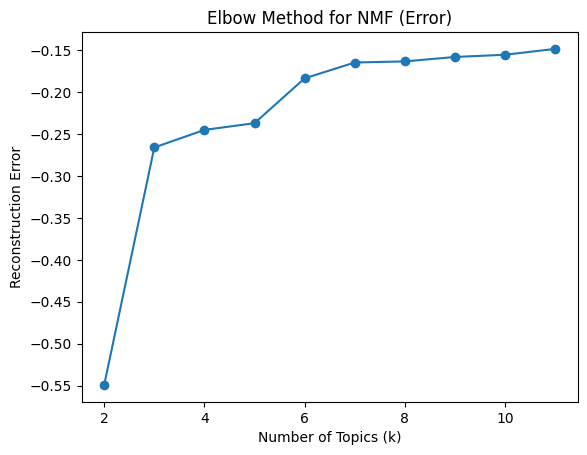

In [31]:
error_diffs = np.diff(errors)
plt.plot(list(topic_range)[1:], error_diffs, marker = 'o')
plt.xlabel("Number of Topics (k)")
plt.ylabel("Reconstruction Error")
plt.title("Elbow Method for NMF (Error)")
plt.show()

## Creating and Training the NMF Model

In [32]:
nmf_model = NMF(n_components = 6, random_state = 42)
nmf_model.fit(dtm)

NMF(n_components=6, random_state=42)

## Visualizing stored words

In [33]:
feature_len = len(tfidf.get_feature_names_out())
print(feature_len)

54777


In [34]:
for i in range(10):
    random_word_id = random.randint(0,54776)
    print(tfidf.get_feature_names_out()[random_word_id])

doctored
intricate
213
valarie
deray
rumblings
acclimated
jog
cement
hoc


In [35]:
for i in range(10):
    random_word_id = random.randint(0,54776)
    print(tfidf.get_feature_names_out()[random_word_id])

ponytail
pertained
meaty
misbehave
ginsburg
sweetwater
dip
featherweight
civilians
physics


## Visualizing Top Words Per Topic

In [36]:
print(len(nmf_model.components_))
print(len(nmf_model.components_[0]))

6
54777


In [37]:
print(nmf_model.components_)

[[2.51205252e-03 2.48574968e-01 0.00000000e+00 ... 1.35022425e-03
  2.37543885e-04 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 8.33367745e-02 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [7.21293294e-03 1.12825973e-01 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 2.98785748e-02 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [5.81082292e-03 0.00000000e+00 1.54589796e-03 ... 7.31753616e-04
  5.79090426e-04 7.13008304e-04]]


In [38]:
single_topic = nmf_model.components_[0]

In [39]:
single_topic.argsort()[-10:]

array([53152,  9156, 19307, 54692, 47218, 36310, 36283, 43172, 47210,
       42993])

In [40]:
top_word_indices = single_topic.argsort()[-10:]

In [41]:
for index in top_word_indices:
    print(tfidf.get_feature_names_out()[index])

water
children
food
zika
study
percent
people
school
students
says


## Getting top 15 words from every topic

In [42]:
for index,topic in enumerate(nmf_model.components_):
    print('\n')
    print(f'THE TOP 15 WORDS FOR TOPIC #{index + 1}')
    print([tfidf.get_feature_names_out()[i] for i in topic.argsort()[-15:]])



THE TOP 15 WORDS FOR TOPIC #1
['research', 'like', 'university', 'education', 'schools', 'water', 'children', 'food', 'zika', 'study', 'percent', 'people', 'school', 'students', 'says']


THE TOP 15 WORDS FOR TOPIC #2
['comey', 'pence', 'presidential', 'russia', 'administration', 'election', 'republican', 'obama', 'white', 'house', 'donald', 'campaign', 'said', 'president', 'trump']


THE TOP 15 WORDS FOR TOPIC #3
['senate', 'house', 'act', 'people', 'tax', 'plan', 'law', 'republicans', 'affordable', 'obamacare', 'coverage', 'medicaid', 'insurance', 'care', 'health']


THE TOP 15 WORDS FOR TOPIC #4
['officers', 'syria', 'security', 'department', 'russia', 'isis', 'law', 'government', 'state', 'attack', 'president', 'reports', 'court', 'said', 'police']


THE TOP 15 WORDS FOR TOPIC #5
['primary', 'cruz', 'election', 'democrats', 'percent', 'party', 'delegates', 'vote', 'state', 'democratic', 'hillary', 'campaign', 'voters', 'sanders', 'clinton']


THE TOP 15 WORDS FOR TOPIC #6
['don',

## Inferencing on the training set

In [43]:
topic_results = nmf_model.transform(dtm)

In [44]:
topic_results[0].argmax()

np.int64(1)

## Visualizing with training set

In [45]:
topic_results.argmax(axis=1)

array([1, 1, 1, ..., 0, 4, 3])

In [46]:
npr['Topic'] = topic_results.argmax(axis=1)

In [47]:
npr.head(10)

,Article,Topic
0,"In the Washington of 2016, even when the polic...",1
1,Donald Trump has used Twitter — his prefe...,1
2,Donald Trump is unabashedly praising Russian...,1
3,"Updated at 2:50 p. m. ET, Russian President Vl...",3
4,"From photography, illustration and video, to d...",3
5,I did not want to join yoga class. I hated tho...,5
6,With a who has publicly supported the debunk...,0
7,"I was standing by the airport exit, debating w...",0
8,"If movies were trying to be more realistic, pe...",0
9,"Eighteen years ago, on New Year’s Eve, David F...",5
